In [1]:
# import sys
# sys.path.insert(0, '/home/runerce/Desktop/DFT-project-2026/ase/ase')

In [4]:
import numpy as np                                                                                                      
from gpaw.occupations import create_occ_calc                                                                            
from gpaw.spinorbit import soc_eigenstates                                                                              
from gpaw.new.ase_interface import GPAW   

In [5]:
def sphere_points(distance=None):                                                                                       
    '''Calculates equidistant points on the upper half sphere                                                           
                                                                                                                        
    Returns list of spherical coordinates (thetas, phis) in degrees                                                     
                                                                                                                        
    Modified from:                                                                                                      
        M. Deserno 2004 If Polymerforshung (Ed.) 2 99                                                                   
    '''                                                                                                                 
                                                                                                                        
    import math                                                                                                         
    N = math.ceil(129600 / (math.pi) * 1 / distance**2)                                                                 
    if N <= 1:                                                                                                          
        return np.array([0.]), np.array([0.])                                                                           
                                                                                                                        
    A = 4 * math.pi                                                                                                     
    a = A / N                                                                                                           
    d = math.sqrt(a)                                                                                                    
                                                                                                                        
    # Even number of theta angles ensure 90 deg is included                                                             
    Mtheta = round(math.pi / (2 * d)) * 2                                                                               
    dtheta = math.pi / Mtheta                                                                                           
    dphi = a / dtheta                                                                                                   
    points = []                                                                                                         
                                                                                                                        
    # Limit theta loop to upper half-sphere                                                                             
    for m in range(Mtheta // 2 + 1):                                                                                    
        # m = 0 ensure 0 deg is included, Mphi = 1 is used in this case                                                 
        theta = math.pi * m / Mtheta                                                                                    
        Mphi = max(round(2 * math.pi * math.sin(theta) / dphi), 1)                                                      
        for n in range(Mphi):                                                                                           
            phi = 2 * math.pi * n / Mphi                                                                                
            points.append([theta, phi])                                                                                 
    thetas, phis = np.array(points).T                                                                                   
                                                                                                                        
    if not any(thetas - np.pi / 2 < 1e-14):                                                                             
        import warnings                                                                                                 
        warnings.warn('xy-plane not included in sampling')                                                              
                                                                                                                        
    return thetas * 180 / math.pi, phis * 180 / math.pi        

In [8]:
theta_tp, phi_tp = sphere_points(distance=5)                                                                            
calc = GPAW('../MnI2_SCF_GS.gpw')                                                                                             
occcalc = create_occ_calc({'name': 'fermi-dirac', 'width': 0.001})                                                      
soc_tp = np.array([])                                                                                                   
for theta, phi in zip(theta_tp, phi_tp):                                                                                
    en_soc = soc_eigenstates(calc=calc, projected=False, theta=theta, phi=phi,                                          
                             occcalc=occcalc).calculate_band_energy()                                                   
    soc_tp = np.append(soc_tp, en_soc)                                                                                  
                                                                                                                        
np.savez('soc_data.npz', soc=soc_tp, theta=theta_tp, phi=phi_tp)                                           

In [12]:
def stereo_project_point(inpoint, axis=0, r=1):                                                                         
    point = np.divide(inpoint * r, inpoint[axis] + r)                                                                   
    point[axis] = 0                                                                                                     
    return point          

def plot_circle(socdata, name='SOC_plot',save=True,):
    from matplotlib.colors import Normalize                                                                                 
    from matplotlib import pyplot as plt                                                                                    
    from scipy.interpolate import griddata                                                                                  
    import numpy as np                                                                                                      
    
    # Load data from nii2_soc.py                                                                                            
    data = np.load(socdata)                                                                                          
    theta, phi = data['theta'], data['phi']                                                                                 
    soc = (data['soc'] - min(data['soc'])) * 10**3                                                                          
                                                                                                                            
    # Convert angles to xyz coordinates                                                                                     
    theta = theta * np.pi / 180                                                                                             
    phi = phi * np.pi / 180                                                                                                 
    x = np.sin(theta) * np.cos(phi)                                                                                         
    y = np.sin(theta) * np.sin(phi)                                                                                         
    z = np.cos(theta)                                                                                                       
    points = np.array([x, y, z]).T                                                                                          
                                                                                                                            
    # Calculate stereographically project points                                                                            
    projected_points = []                                                                                                   
    for p in points:                                                                                                        
        projected_points.append(stereo_project_point(p, axis=2))                                                            
                                                                                                                            
    fig, ax = plt.subplots(1, 1, figsize=(5 * 1.25, 5))                                                                     
                                                                                                                            
    # Plot contour surface                                                                                                  
    norm = Normalize(vmin=min(soc), vmax=max(soc))                                                                          
    X, Y, Z = np.array(projected_points).T                                                                                  
    xi = np.linspace(min(X), max(X), 100)                                                                                   
    yi = np.linspace(min(Y), max(Y), 100)                                                                                   
    zi = griddata((X, Y), soc, (xi[None, :], yi[:, None]))                                                                  
    ax.contour(xi, yi, zi, 15, linewidths=0.5, colors='k', norm=norm)                                                       
    ax.contourf(xi, yi, zi, 15, cmap=plt.cm.jet, norm=norm)                                                                 
                                                                                                                            
    # Add additional contours                                                                                               
    mask = np.argwhere(soc <= np.min(soc) + 0.05)                                                                           
    #ax.scatter(X[mask], Y[mask], marker='o', c='midnightblue', s=5)                                                        
    mask = np.argwhere(soc <= np.min(soc) + 0.001)                                                                          
    #ax.scatter(X[mask], Y[mask], marker='o', c='k', s=5)                                                                   
    # Spin-orbit energy minimum                                                                                             
    mask = np.argwhere(soc <= np.min(soc))                                                                                  
    #ax.scatter(X[mask], Y[mask], marker='o', c='white', s=5)                                                               
    # z-axis direction                                                                                                      
    #ax.scatter(X[0], Y[0], marker='o', c='k', s=10)                                                                        
                                                                                                                            
    theta_min = round(theta[mask][0][0] * 180 / np.pi, 2)                                                                   
    phi_min = round(phi[mask][0][0] * 180 / np.pi, 2)                                                                       
    print(f'n = (theta, phi) = ({theta_min}, {phi_min})')                                                                   
                                                                                                                            
    # Set plot details                                                                                                      
    ax.axis('equal')                                                                                                        
    ax.set_xlim(-1.05, 1.05)                                                                                                
    ax.set_ylim(-1.05, 1.05)                                                                                                
    ax.set_xticks([])                                                                                                       
    ax.set_yticks([])                                                                                                       
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='jet'), ax=ax)                                                
    cbar.ax.set_ylabel(r'$E_{soc} [meV]$')                                                                                  
                                                                                                                            
    # Save figure   
    if save:
        plt.savefig(name)                                                                                                         
    plt.show()
                                                                                                   

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


n = (theta, phi) = (0.0, 0.0)


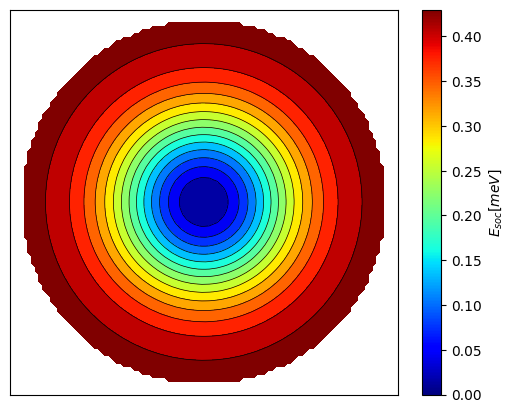

In [15]:
plot_circle('soc_data.npz',name='test', save=False)